In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import time

In [2]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

train_data.head()

Training data shape: (42000, 785)
Testing data shape: (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
print("Dataset information:")
print(train_data.info())

print("\nMissing values:")
print(train_data.isnull().sum().sum())

print("\nDuplicate rows:")
print(train_data.duplicated().sum())

print("\nStatistical summary:")
print(train_data.describe())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB
None

Missing values:
0

Duplicate rows:
0

Statistical summary:
              label   pixel0   pixel1   pixel2   pixel3   pixel4   pixel5  \
count  42000.000000  42000.0  42000.0  42000.0  42000.0  42000.0  42000.0   
mean       4.456643      0.0      0.0      0.0      0.0      0.0      0.0   
std        2.887730      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
25%        2.000000      0.0      0.0      0.0      0.0      0.0      0.0   
50%        4.000000      0.0      0.0      0.0      0.0      0.0      0.0   
75%        7.000000      0.0      0.0      0.0      0.0      0.0      0.0   
max        9.000000      0.0      0.0      0.0      0.0      0.0      0.0   

        pixel6   pixel7   pixel8  ...      pixel774      pixel

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


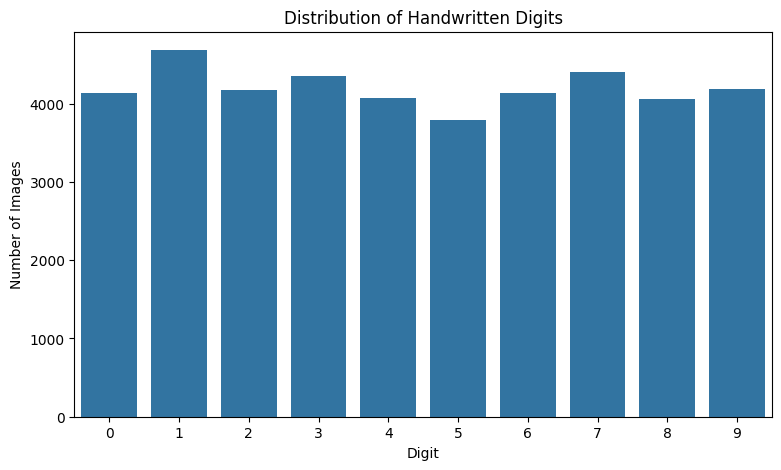

In [4]:
digit_count = train_data["label"].value_counts().sort_index()

print(digit_count)

plt.figure(figsize=(9, 5))
sns.barplot(x=digit_count.index, y=digit_count.values)

plt.title("Distribution of Handwritten Digits")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(range(10))
plt.show()

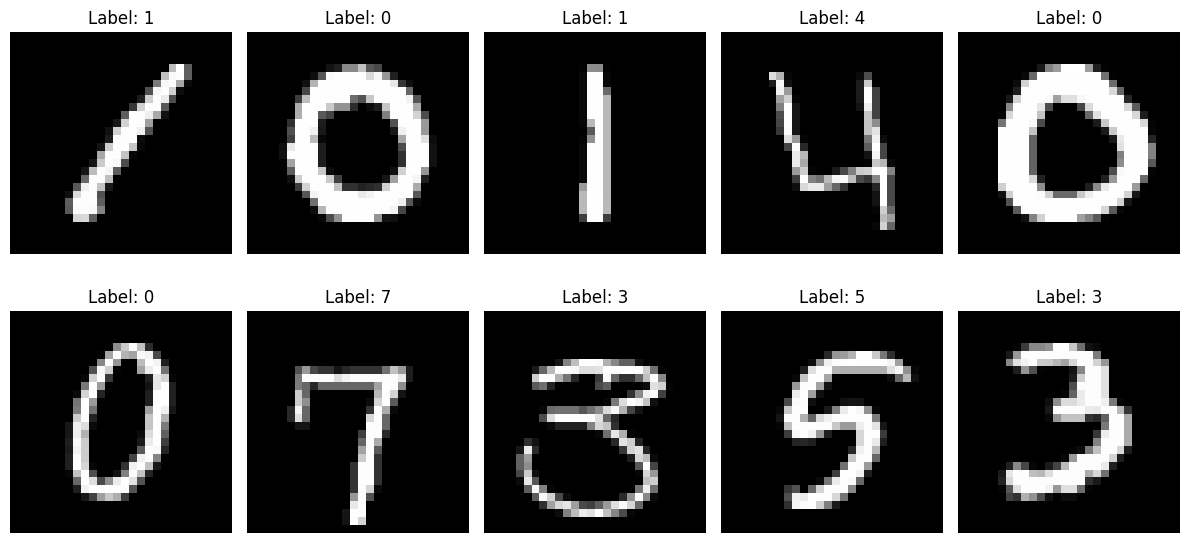

In [5]:
pixels = train_data.drop("label", axis=1).values
labels = train_data["label"].values

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = pixels[i].reshape(28, 28)

    plt.imshow(image, cmap="gray")
    plt.title("Label: " + str(labels[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

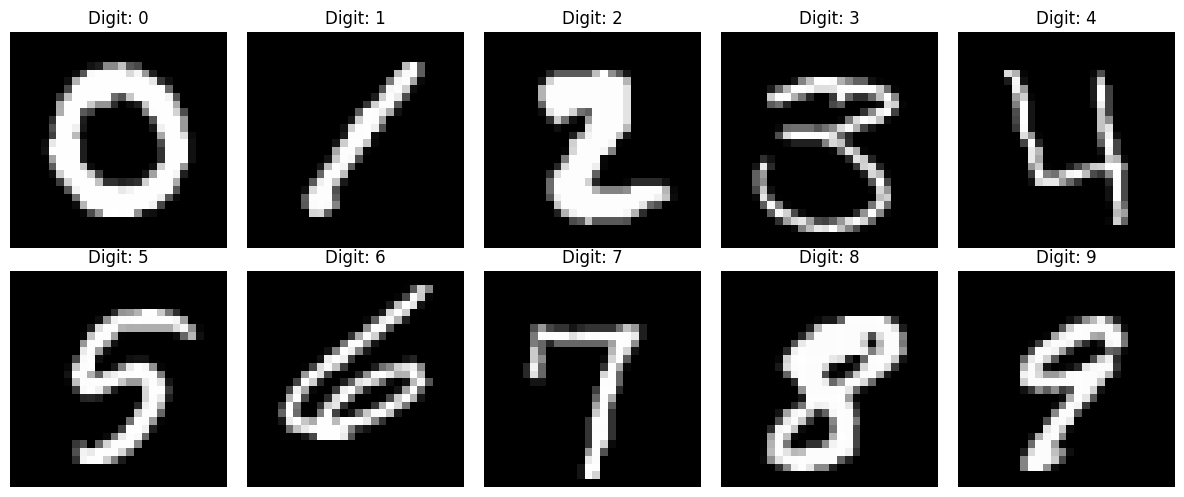

In [6]:
plt.figure(figsize=(12, 5))

for digit in range(10):
    index = np.where(labels == digit)[0][0]

    image = pixels[index].reshape(28, 28)

    plt.subplot(2, 5, digit + 1)
    plt.imshow(image, cmap="gray")
    plt.title("Digit: " + str(digit))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
X = train_data.drop("label", axis=1).values
y = train_data["label"].values

# Normalize pixel values
X = X.astype(np.float32) / 255.0

# One-hot encoding
Y = np.zeros((y.shape[0], 10), dtype=np.float32)
Y[np.arange(y.shape[0]), y] = 1

# Split into training and validation data
X_train, X_val, Y_train, Y_val, y_train, y_val = train_test_split(
    X, Y, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

X_train: (33600, 784)
Y_train: (33600, 10)
X_val: (8400, 784)
Y_val: (8400, 10)


In [8]:
class ANN:
    def __init__(self, input_size, hidden_layers, output_size, learning_rate=0.01):
        self.learning_rate = learning_rate

        self.layers = [input_size] + hidden_layers + [output_size]

        self.weights = []
        self.biases = []

        # He initialization for ReLU layers
        for i in range(len(self.layers) - 1):
            input_neurons = self.layers[i]
            output_neurons = self.layers[i + 1]

            W = np.random.randn(input_neurons, output_neurons) * np.sqrt(2.0 / input_neurons)
            b = np.zeros((1, output_neurons))

            self.weights.append(W)
            self.biases.append(b)

    # ReLU activation
    def relu(self, Z):
        return np.maximum(0, Z)

    # Derivative of ReLU
    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    # Softmax activation
    def softmax(self, Z):
        Z = Z - np.max(Z, axis=1, keepdims=True)
        exp_values = np.exp(Z)
        return exp_values / np.sum(exp_values, axis=1, keepdims=True)

    # Forward propagation
    def forward(self, X):
        self.A = [X]
        self.Z = []

        A = X

        for i in range(len(self.weights) - 1):
            Z = np.dot(A, self.weights[i]) + self.biases[i]
            A = self.relu(Z)

            self.Z.append(Z)
            self.A.append(A)

        # Output layer
        Z = np.dot(A, self.weights[-1]) + self.biases[-1]
        A = self.softmax(Z)

        self.Z.append(Z)
        self.A.append(A)

        return A

    # Cross-entropy loss
    def loss(self, Y, predictions):
        epsilon = 1e-12
        predictions = np.clip(predictions, epsilon, 1.0 - epsilon)

        loss = -np.sum(Y * np.log(predictions)) / Y.shape[0]
        return loss

    # Backpropagation
    def backward(self, Y):
        m = Y.shape[0]

        dW = [None] * len(self.weights)
        db = [None] * len(self.biases)

        # Output layer gradient
        dZ = self.A[-1] - Y

        dW[-1] = np.dot(self.A[-2].T, dZ) / m
        db[-1] = np.sum(dZ, axis=0, keepdims=True) / m

        # Hidden layer gradients
        for i in range(len(self.weights) - 2, -1, -1):
            dA = np.dot(dZ, self.weights[i + 1].T)

            dZ = dA * self.relu_derivative(self.Z[i])

            dW[i] = np.dot(self.A[i].T, dZ) / m
            db[i] = np.sum(dZ, axis=0, keepdims=True) / m

        # Update weights and biases
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * dW[i]
            self.biases[i] -= self.learning_rate * db[i]

    # Predict digit labels
    def predict(self, X):
        predictions = self.forward(X)
        return np.argmax(predictions, axis=1)

    # Calculate accuracy
    def accuracy(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

In [9]:
def train_model(model, X_train, Y_train, y_train, X_val, Y_val, y_val,
                epochs, batch_size):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    n = X_train.shape[0]

    for epoch in range(epochs):
        start_time = time.time()

        # Shuffle training data
        indices = np.random.permutation(n)

        X_shuffled = X_train[indices]
        Y_shuffled = Y_train[indices]

        # Mini-batch gradient descent
        for i in range(0, n, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            Y_batch = Y_shuffled[i:i + batch_size]

            # Forward propagation
            model.forward(X_batch)

            # Backpropagation and weight update
            model.backward(Y_batch)

        # Calculate metrics after the epoch
        train_predictions = model.forward(X_train)
        val_predictions = model.forward(X_val)

        train_loss = model.loss(Y_train, train_predictions)
        val_loss = model.loss(Y_val, val_predictions)

        train_acc = np.mean(np.argmax(train_predictions, axis=1) == y_train)
        val_acc = np.mean(np.argmax(val_predictions, axis=1) == y_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        end_time = time.time()

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Time: {end_time - start_time:.2f}s"
        )

    return history

In [10]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Training Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [11]:
experiments = [
    {
        "name": "Experiment 1",
        "hidden_layers": [64],
        "learning_rate": 0.01,
        "batch_size": 64,
        "epochs": 15
    },
    {
        "name": "Experiment 2",
        "hidden_layers": [128, 64],
        "learning_rate": 0.01,
        "batch_size": 64,
        "epochs": 15
    },
    {
        "name": "Experiment 3",
        "hidden_layers": [256, 128],
        "learning_rate": 0.005,
        "batch_size": 128,
        "epochs": 15
    }
]


Experiment 1
Epoch 1/15 | Train Loss: 0.6260 | Val Loss: 0.6303 | Train Acc: 0.8465 | Val Acc: 0.8449 | Time: 3.05s
Epoch 2/15 | Train Loss: 0.4539 | Val Loss: 0.4594 | Train Acc: 0.8785 | Val Acc: 0.8742 | Time: 2.21s
Epoch 3/15 | Train Loss: 0.3923 | Val Loss: 0.3990 | Train Acc: 0.8924 | Val Acc: 0.8863 | Time: 0.98s
Epoch 4/15 | Train Loss: 0.3576 | Val Loss: 0.3650 | Train Acc: 0.9021 | Val Acc: 0.8962 | Time: 0.98s
Epoch 5/15 | Train Loss: 0.3342 | Val Loss: 0.3427 | Train Acc: 0.9075 | Val Acc: 0.9012 | Time: 0.97s
Epoch 6/15 | Train Loss: 0.3176 | Val Loss: 0.3278 | Train Acc: 0.9106 | Val Acc: 0.9054 | Time: 0.97s
Epoch 7/15 | Train Loss: 0.3047 | Val Loss: 0.3151 | Train Acc: 0.9154 | Val Acc: 0.9085 | Time: 0.97s
Epoch 8/15 | Train Loss: 0.2928 | Val Loss: 0.3038 | Train Acc: 0.9174 | Val Acc: 0.9106 | Time: 0.94s
Epoch 9/15 | Train Loss: 0.2826 | Val Loss: 0.2949 | Train Acc: 0.9210 | Val Acc: 0.9126 | Time: 0.97s
Epoch 10/15 | Train Loss: 0.2744 | Val Loss: 0.2876 | Train

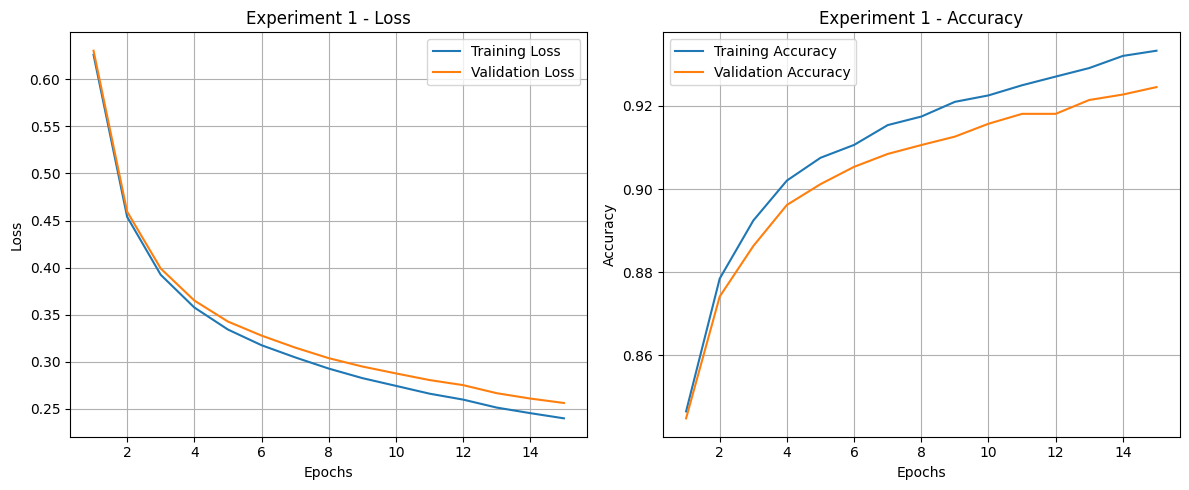


Experiment 2
Epoch 1/15 | Train Loss: 0.5180 | Val Loss: 0.5212 | Train Acc: 0.8652 | Val Acc: 0.8605 | Time: 1.72s
Epoch 2/15 | Train Loss: 0.3701 | Val Loss: 0.3779 | Train Acc: 0.8981 | Val Acc: 0.8939 | Time: 1.75s
Epoch 3/15 | Train Loss: 0.3161 | Val Loss: 0.3266 | Train Acc: 0.9110 | Val Acc: 0.9060 | Time: 1.72s
Epoch 4/15 | Train Loss: 0.2842 | Val Loss: 0.2972 | Train Acc: 0.9199 | Val Acc: 0.9126 | Time: 1.68s
Epoch 5/15 | Train Loss: 0.2624 | Val Loss: 0.2776 | Train Acc: 0.9261 | Val Acc: 0.9176 | Time: 2.08s
Epoch 6/15 | Train Loss: 0.2435 | Val Loss: 0.2604 | Train Acc: 0.9322 | Val Acc: 0.9243 | Time: 4.29s
Epoch 7/15 | Train Loss: 0.2302 | Val Loss: 0.2484 | Train Acc: 0.9371 | Val Acc: 0.9274 | Time: 2.28s
Epoch 8/15 | Train Loss: 0.2170 | Val Loss: 0.2375 | Train Acc: 0.9379 | Val Acc: 0.9306 | Time: 1.70s
Epoch 9/15 | Train Loss: 0.2078 | Val Loss: 0.2291 | Train Acc: 0.9418 | Val Acc: 0.9323 | Time: 1.71s
Epoch 10/15 | Train Loss: 0.1948 | Val Loss: 0.2187 | Train

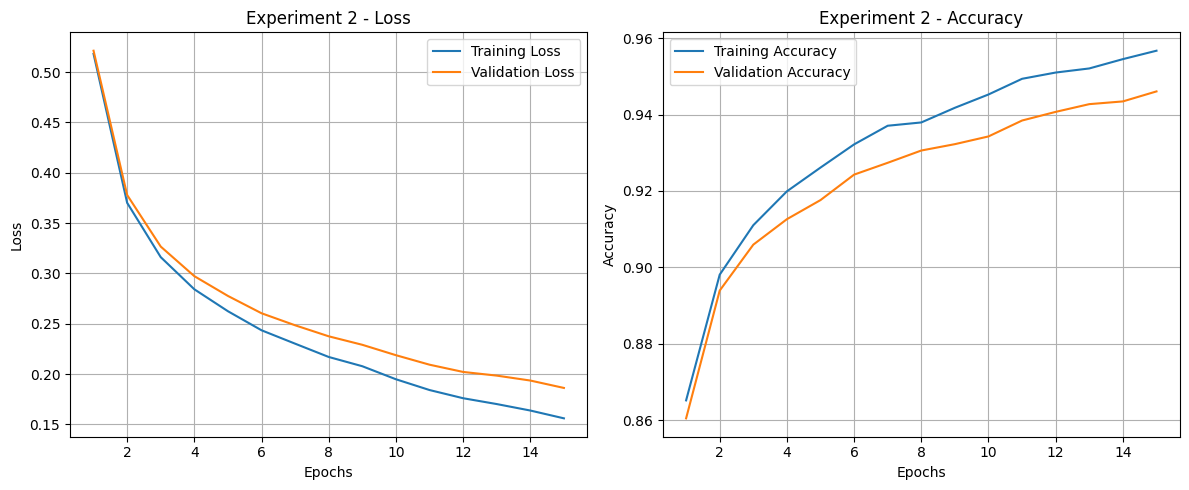


Experiment 3
Epoch 1/15 | Train Loss: 1.2879 | Val Loss: 1.2921 | Train Acc: 0.7294 | Val Acc: 0.7267 | Time: 2.92s
Epoch 2/15 | Train Loss: 0.7590 | Val Loss: 0.7620 | Train Acc: 0.8188 | Val Acc: 0.8177 | Time: 5.84s
Epoch 3/15 | Train Loss: 0.5728 | Val Loss: 0.5752 | Train Acc: 0.8551 | Val Acc: 0.8563 | Time: 2.92s
Epoch 4/15 | Train Loss: 0.4837 | Val Loss: 0.4861 | Train Acc: 0.8743 | Val Acc: 0.8714 | Time: 2.93s
Epoch 5/15 | Train Loss: 0.4308 | Val Loss: 0.4343 | Train Acc: 0.8851 | Val Acc: 0.8820 | Time: 2.92s
Epoch 6/15 | Train Loss: 0.3950 | Val Loss: 0.3988 | Train Acc: 0.8934 | Val Acc: 0.8873 | Time: 5.87s
Epoch 7/15 | Train Loss: 0.3688 | Val Loss: 0.3738 | Train Acc: 0.8991 | Val Acc: 0.8926 | Time: 2.83s
Epoch 8/15 | Train Loss: 0.3493 | Val Loss: 0.3545 | Train Acc: 0.9037 | Val Acc: 0.8993 | Time: 2.82s
Epoch 9/15 | Train Loss: 0.3324 | Val Loss: 0.3390 | Train Acc: 0.9079 | Val Acc: 0.9033 | Time: 4.53s
Epoch 10/15 | Train Loss: 0.3194 | Val Loss: 0.3265 | Train

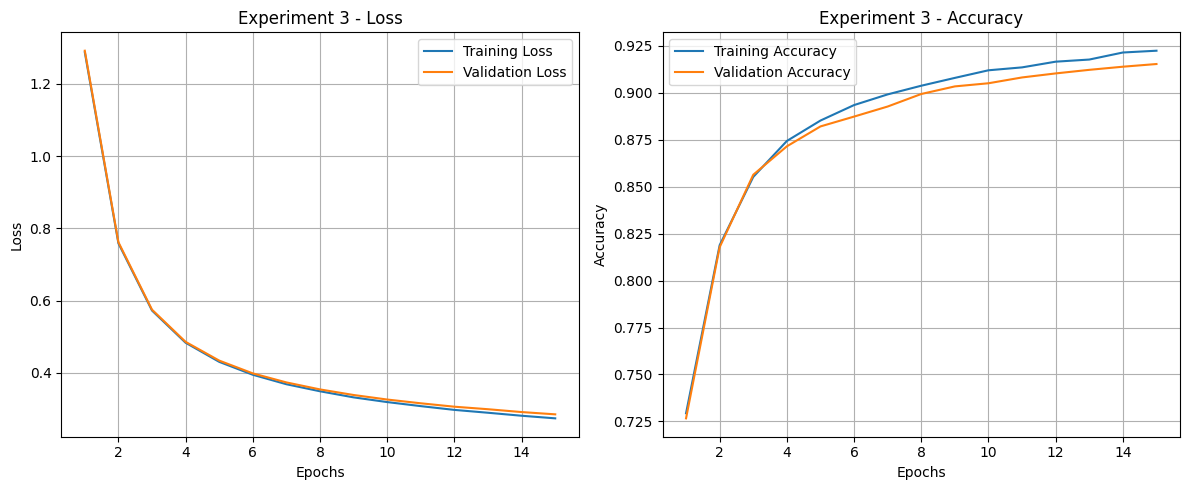

,Experiment,Architecture,Learning Rate,Batch Size,Epochs,Validation Accuracy,Final Training Loss,Final Validation Loss
0,Experiment 1,[64],0.010,64,15,0.924524,0.239907,0.256206
1,Experiment 2,"[128, 64]",0.010,64,15,0.946071,0.156016,0.186212
2,Experiment 3,"[256, 128]",0.005,128,15,0.915238,0.274396,0.285463


In [12]:
np.random.seed(42)

results = []
models = {}
histories = {}

for exp in experiments:
    print("\n", "=" * 60)
    print(exp["name"])
    print("=" * 60)

    model = ANN(
        input_size=784,
        hidden_layers=exp["hidden_layers"],
        output_size=10,
        learning_rate=exp["learning_rate"]
    )

    history = train_model(
        model,
        X_train, Y_train, y_train,
        X_val, Y_val, y_val,
        exp["epochs"],
        exp["batch_size"]
    )

    val_predictions = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_predictions)

    results.append({
        "Experiment": exp["name"],
        "Architecture": str(exp["hidden_layers"]),
        "Learning Rate": exp["learning_rate"],
        "Batch Size": exp["batch_size"],
        "Epochs": exp["epochs"],
        "Validation Accuracy": val_accuracy,
        "Final Training Loss": history["train_loss"][-1],
        "Final Validation Loss": history["val_loss"][-1]
    })

    models[exp["name"]] = model
    histories[exp["name"]] = history

    plot_history(history, exp["name"])

results_df = pd.DataFrame(results)
results_df

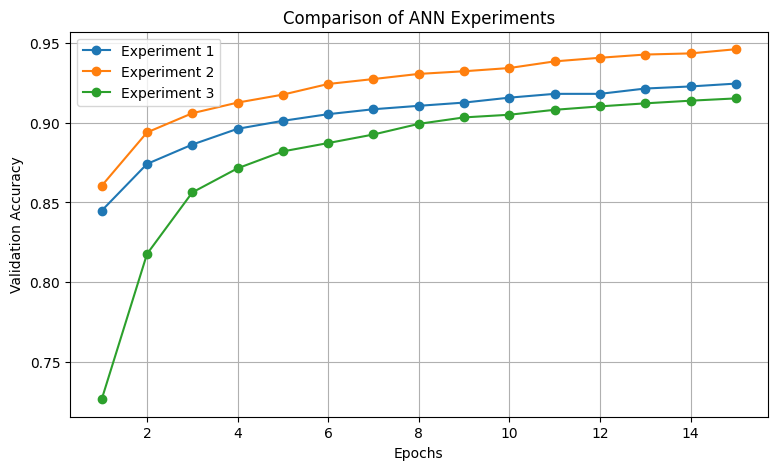

In [13]:
plt.figure(figsize=(9, 5))

for name, history in histories.items():
    plt.plot(
        range(1, len(history["val_acc"]) + 1),
        history["val_acc"],
        marker="o",
        label=name
    )

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Comparison of ANN Experiments")
plt.legend()
plt.grid(True)
plt.show()

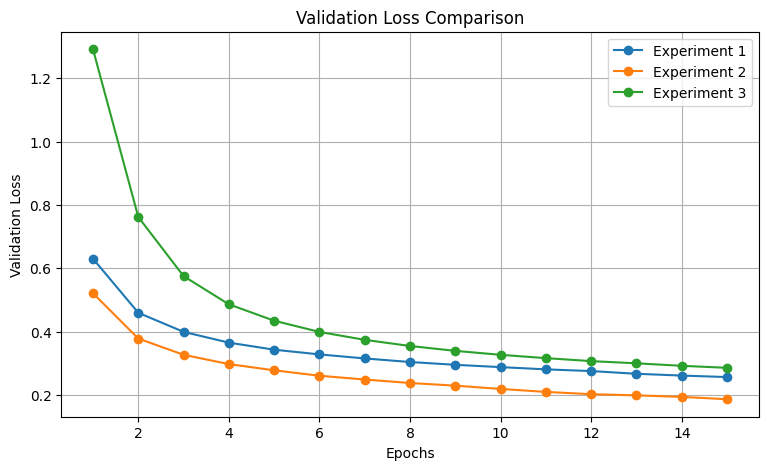

In [14]:
plt.figure(figsize=(9, 5))

for name, history in histories.items():
    plt.plot(
        range(1, len(history["val_loss"]) + 1),
        history["val_loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
best_index = results_df["Validation Accuracy"].idxmax()
best_name = results_df.loc[best_index, "Experiment"]

best_model = models[best_name]
best_history = histories[best_name]

print("Best experiment:", best_name)
print(
    "Best validation accuracy:",
    results_df.loc[best_index, "Validation Accuracy"]
)

Best experiment: Experiment 2
Best validation accuracy: 0.9460714285714286


In [16]:
y_pred = best_model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average="macro", zero_division=0)
recall = recall_score(y_val, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)

print("Final Model Evaluation")
print("-" * 35)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred, zero_division=0))

Final Model Evaluation
-----------------------------------
Accuracy  : 0.9461
Precision : 0.9460
Recall    : 0.9452
F1-score  : 0.9455

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       827
           1       0.96      0.98      0.97       937
           2       0.95      0.95      0.95       835
           3       0.91      0.93      0.92       870
           4       0.95      0.94      0.95       814
           5       0.93      0.91      0.92       759
           6       0.97      0.98      0.97       827
           7       0.95      0.96      0.96       880
           8       0.95      0.91      0.93       813
           9       0.91      0.93      0.92       838

    accuracy                           0.95      8400
   macro avg       0.95      0.95      0.95      8400
weighted avg       0.95      0.95      0.95      8400



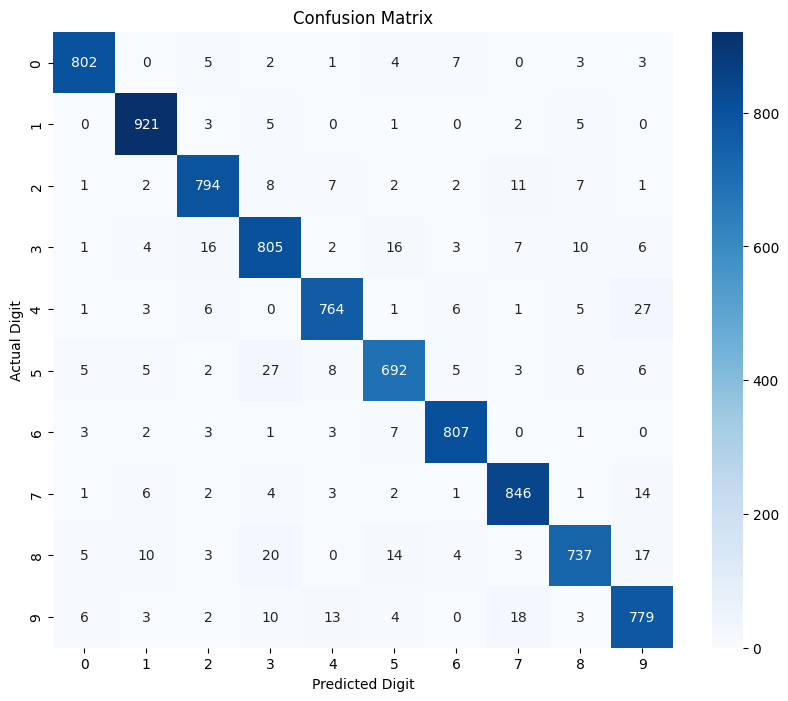

In [17]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Confusion Matrix")
plt.show()

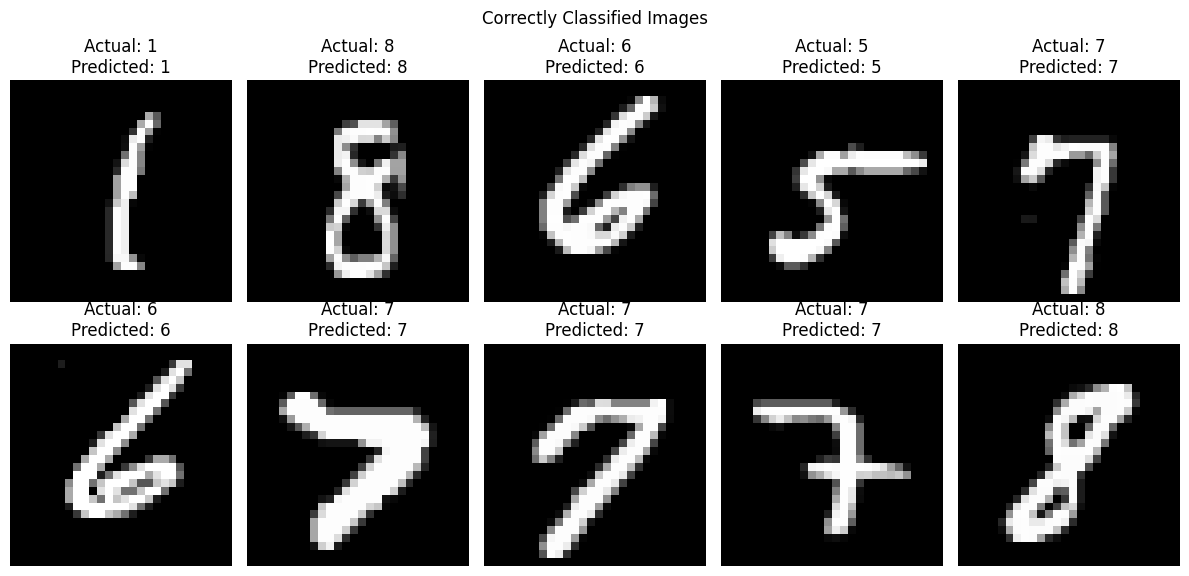

In [18]:
correct_indices = np.where(y_pred == y_val)[0]

plt.figure(figsize=(12, 6))

for i in range(min(10, len(correct_indices))):
    index = correct_indices[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_val[index].reshape(28, 28), cmap="gray")

    plt.title(
        f"Actual: {y_val[index]}\nPredicted: {y_pred[index]}"
    )

    plt.axis("off")

plt.suptitle("Correctly Classified Images")
plt.tight_layout()
plt.show()

Total misclassified images: 453


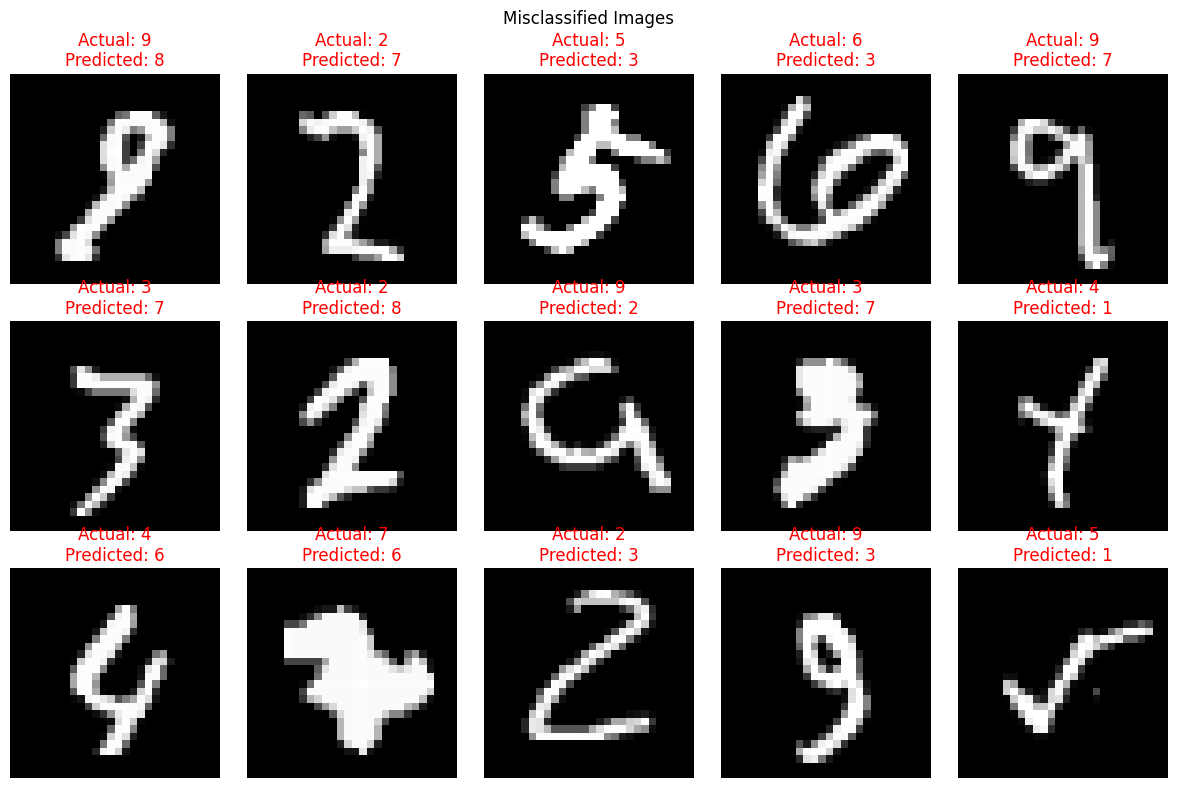

In [19]:
wrong_indices = np.where(y_pred != y_val)[0]

print("Total misclassified images:", len(wrong_indices))

plt.figure(figsize=(12, 8))

for i in range(min(15, len(wrong_indices))):
    index = wrong_indices[i]

    plt.subplot(3, 5, i + 1)
    plt.imshow(X_val[index].reshape(28, 28), cmap="gray")

    plt.title(
        f"Actual: {y_val[index]}\nPredicted: {y_pred[index]}",
        color="red"
    )

    plt.axis("off")

plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()

In [20]:
error_pairs = pd.DataFrame({
    "Actual": y_val[wrong_indices],
    "Predicted": y_pred[wrong_indices]
})

error_count = error_pairs.value_counts().reset_index(name="Count")
error_count = error_count.sort_values("Count", ascending=False)

print("Most common classification errors:")
print(error_count.head(10))

Most common classification errors:
   Actual  Predicted  Count
0       5          3     27
1       4          9     27
2       8          3     20
3       9          7     18
4       8          9     17
5       3          5     16
6       3          2     16
7       7          9     14
8       8          5     14
9       9          4     13


In [21]:
X_test = test_data.values.astype(np.float32) / 255.0

print("Test data shape:", X_test.shape)

test_predictions = best_model.predict(X_test)

print("Predictions:", test_predictions[:20])

Test data shape: (28000, 784)
Predictions: [2 0 9 9 3 7 0 3 0 3 5 7 4 0 4 3 3 1 9 0]


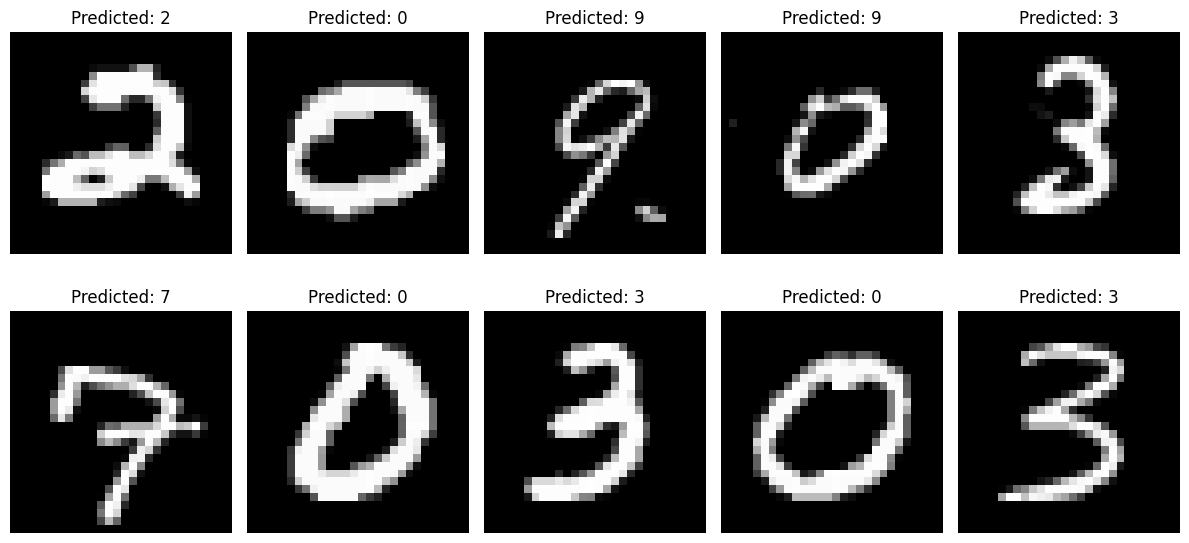

In [22]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = X_test[i].reshape(28, 28)

    plt.imshow(image, cmap="gray")
    plt.title("Predicted: " + str(test_predictions[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_predictions) + 1),
    "Label": test_predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("Submission file created successfully!")
submission.head()

Submission file created successfully!


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [26]:
print("EXPERIMENT COMPARISON")
print("=" * 70)

print(
    results_df.sort_values(
        by="Validation Accuracy",
        ascending=False
    ).to_string(index=False)
)

print("\nSelected model:", best_name)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")

EXPERIMENT COMPARISON
  Experiment Architecture  Learning Rate  Batch Size  Epochs  Validation Accuracy  Final Training Loss  Final Validation Loss
Experiment 2    [128, 64]          0.010          64      15             0.946071             0.156016               0.186212
Experiment 1         [64]          0.010          64      15             0.924524             0.239907               0.256206
Experiment 3   [256, 128]          0.005         128      15             0.915238             0.274396               0.285463

Selected model: Experiment 2
Accuracy: 94.61%
Precision: 94.60%
Recall: 94.52%
F1-score: 94.55%
